In [6]:
import numpy as np
import pandas as pd
import scipy.optimize

In [7]:
data_full = pd.read_table("../data/Pantheon_SH0ES.dat", delimiter=" ")
print(len(data_full))
print(data_full.columns)
data_full.head()

1701
Index(['CID', 'IDSURVEY', 'zHD', 'zHDERR', 'zCMB', 'zCMBERR', 'zHEL',
       'zHELERR', 'm_b_corr', 'm_b_corr_err_DIAG', 'MU_SH0ES',
       'MU_SH0ES_ERR_DIAG', 'CEPH_DIST', 'IS_CALIBRATOR', 'USED_IN_SH0ES_HF',
       'c', 'cERR', 'x1', 'x1ERR', 'mB', 'mBERR', 'x0', 'x0ERR', 'COV_x1_c',
       'COV_x1_x0', 'COV_c_x0', 'RA', 'DEC', 'HOST_RA', 'HOST_DEC',
       'HOST_ANGSEP', 'VPEC', 'VPECERR', 'MWEBV', 'HOST_LOGMASS',
       'HOST_LOGMASS_ERR', 'PKMJD', 'PKMJDERR', 'NDOF', 'FITCHI2', 'FITPROB',
       'm_b_corr_err_RAW', 'm_b_corr_err_VPEC', 'biasCor_m_b',
       'biasCorErr_m_b', 'biasCor_m_b_COVSCALE', 'biasCor_m_b_COVADD'],
      dtype='str')


,CID,IDSURVEY,zHD,zHDERR,zCMB,zCMBERR,zHEL,zHELERR,m_b_corr,m_b_corr_err_DIAG,...,PKMJDERR,NDOF,FITCHI2,FITPROB,m_b_corr_err_RAW,m_b_corr_err_VPEC,biasCor_m_b,biasCorErr_m_b,biasCor_m_b_COVSCALE,biasCor_m_b_COVADD
0,2011fe,51,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.74571,1.516210,...,0.1071,36,26.8859,0.864470,0.0991,1.4960,0.0381,0.005,1.0,0.003
1,2011fe,56,0.00122,0.00084,0.00122,0.00002,0.00082,0.00002,9.80286,1.517230,...,0.0579,101,88.3064,0.812220,0.0971,1.4960,-0.0252,0.003,1.0,0.004
2,2012cg,51,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.47030,0.781906,...,0.0278,165,233.5000,0.000358,0.0399,0.7134,0.0545,0.019,1.0,0.036
3,2012cg,56,0.00256,0.00084,0.00256,0.00002,0.00144,0.00002,11.49190,0.798612,...,0.0667,55,100.1220,0.000193,0.0931,0.7134,0.0622,0.028,1.0,0.040
4,1994DRichmond,50,0.00299,0.00084,0.00299,0.00004,0.00187,0.00004,11.52270,0.880798,...,0.0522,146,109.8390,0.988740,0.0567,0.6110,0.0650,0.009,1.0,0.006


In [8]:
data_calib = data_full.loc[(data_full["IS_CALIBRATOR"] == 1)]
data_hf = data_full.loc[(data_full["USED_IN_SH0ES_HF"] == 1)]

In [9]:
from dataclasses import dataclass


@dataclass
class SNSample:
    m_b: np.ndarray
    m_b_err: np.ndarray
    id_map: np.ndarray
    unique_sn_count: int

    @staticmethod
    def prepare(d: pd.DataFrame, is_hf=False) -> "SNSample":
        mu = d["m_b_corr"].to_numpy()
        sigma2 = d["m_b_corr_err_RAW"] ** 2 + d["biasCorErr_m_b"] ** 2
        if is_hf:
            sigma2 += d["m_b_corr_err_VPEC"]
        sigma = (sigma2**0.5).to_numpy()

        unique_cids = sorted(d["CID"].unique())
        unique_sn_count = len(unique_cids)

        id_map = np.zeros(len(d), dtype=int)
        for i, cid in enumerate(d["CID"]):
            id_map[i] = unique_cids.index(cid)

        return SNSample(m_b=mu, m_b_err=sigma, id_map=id_map, unique_sn_count=unique_sn_count)

In [34]:
calib_sample = SNSample.prepare(data_calib, False)


def m_b_calib(Mj: np.ndarray) -> np.ndarray:
    # assert Mj.size == calib_sample.unique_sn_count
    return Mj[calib_sample.id_map] + data_calib["CEPH_DIST"]

In [11]:
calib_sample.id_map

array([29, 29, 30, 30,  0, 33, 33, 36, 36, 11, 28,  6,  1, 41, 18, 19, 34,
       34, 32, 32, 31, 31, 35, 35, 24, 24,  2, 38, 38, 38, 23, 23, 23, 23,
       39, 39,  3, 37, 37, 37, 17, 17, 17, 14, 14, 15, 15, 15,  7,  7, 27,
       27, 27, 10, 16, 42,  4, 20, 20, 20,  8,  8, 12, 12, 26, 26, 26, 21,
       40, 13, 13,  5, 25,  9,  9, 22, 22])

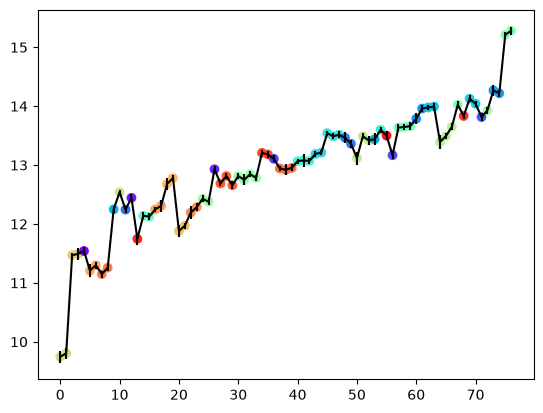

In [12]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots()
ax.errorbar(np.arange(len(calib_sample.m_b)), calib_sample.m_b, yerr=calib_sample.m_b_err, color="k")

cmap = plt.get_cmap("rainbow")
ax.scatter(
    np.arange(len(calib_sample.m_b)),
    calib_sample.m_b,
    color=cmap(calib_sample.id_map / calib_sample.unique_sn_count),
    marker="o",
)

In [13]:
calib_sample.id_map / calib_sample.unique_sn_count

array([0.6744186 , 0.6744186 , 0.69767442, 0.69767442, 0.        ,
       0.76744186, 0.76744186, 0.8372093 , 0.8372093 , 0.25581395,
       0.65116279, 0.13953488, 0.02325581, 0.95348837, 0.41860465,
       0.44186047, 0.79069767, 0.79069767, 0.74418605, 0.74418605,
       0.72093023, 0.72093023, 0.81395349, 0.81395349, 0.55813953,
       0.55813953, 0.04651163, 0.88372093, 0.88372093, 0.88372093,
       0.53488372, 0.53488372, 0.53488372, 0.53488372, 0.90697674,
       0.90697674, 0.06976744, 0.86046512, 0.86046512, 0.86046512,
       0.39534884, 0.39534884, 0.39534884, 0.3255814 , 0.3255814 ,
       0.34883721, 0.34883721, 0.34883721, 0.1627907 , 0.1627907 ,
       0.62790698, 0.62790698, 0.62790698, 0.23255814, 0.37209302,
       0.97674419, 0.09302326, 0.46511628, 0.46511628, 0.46511628,
       0.18604651, 0.18604651, 0.27906977, 0.27906977, 0.60465116,
       0.60465116, 0.60465116, 0.48837209, 0.93023256, 0.30232558,
       0.30232558, 0.11627907, 0.58139535, 0.20930233, 0.20930

In [14]:
from astropy import units as u
from astropy.cosmology import WMAP9 as cosmo

D_L_ref = np.array([cosmo.luminosity_distance(z).to(u.Mpc).value for z in data_hf["zHD"]])

In [32]:
hf_sample = SNSample.prepare(data_hf, is_hf=True)


def m_b_hf(H0: float, Mj: np.ndarray) -> np.ndarray:
    # assert Mj.size == hf_sample.unique_sn_count, (
    #     f"Mj supplied ({Mj}) has size {Mj.size}, expected {hf_sample.unique_sn_count}"
    # )
    D_L = D_L_ref * (cosmo.H0.value / H0)
    return 25 + 5 * np.log10(D_L) + Mj[hf_sample.id_map]

In [16]:
def unpack(theta: np.ndarray) -> tuple[float, float, float, np.ndarray, np.ndarray]:
    H0: float = theta[0]
    M_B: float = theta[1]
    sigma_int: float = theta[2]
    Mj_hf: np.ndarray = theta[3 : hf_sample.unique_sn_count + 3]
    Mj_calib: np.ndarray = theta[hf_sample.unique_sn_count + 3 :]
    return H0, M_B, sigma_int, Mj_hf, Mj_calib


def loglike(H0: float, M_B: float, sigma_int: float, Mj_hf: np.ndarray, Mj_calib: np.ndarray) -> float:
    return -0.5 * (
        np.sum(((Mj_hf - M_B) / sigma_int) ** 2)  # Mj prior folded into the likelihood
        + np.sum(((Mj_calib - M_B) / sigma_int) ** 2)
        + np.sum(((hf_sample.m_b - m_b_hf(H0, Mj_hf)) / hf_sample.m_b_err) ** 2)
        + np.sum(((calib_sample.m_b - m_b_calib(Mj_calib)) / calib_sample.m_b_err) ** 2)
    ) - (len(Mj_hf) + len(Mj_calib)) * np.log(sigma_int)

In [17]:
def logpost(theta: np.ndarray) -> float:
    H0, M_b, sigma, Mj_hf, Mj_calib = unpack(theta)
    if H0 < 0:
        return -np.inf
    if sigma <= 0:
        return -np.inf
    logprior = -0.5 * (sigma / 0.2) ** 2
    return loglike(H0, M_b, sigma, Mj_hf, Mj_calib) + logprior

In [18]:
x0 = np.array(
    [
        70,
        -19.3,
        0.1,
        *[-19.3] * hf_sample.unique_sn_count,
        *[-19.3] * calib_sample.unique_sn_count,
    ]
)

res = scipy.optimize.minimize(fun=lambda x: -logpost(x), x0=x0, method="Nelder-Mead", options={"maxiter": 100000})
print(res)

       message: Maximum number of iterations has been exceeded.
       success: False
        status: 2
           fun: -2118.6415082125427
             x: [ 7.142e+01 -1.932e+01 ... -1.932e+01 -1.932e+01]
           nit: 100000
          nfev: 106211
 final_simplex: (array([[ 7.142e+01, -1.932e+01, ..., -1.932e+01,
                        -1.932e+01],
                       [ 7.142e+01, -1.932e+01, ..., -1.932e+01,
                        -1.932e+01],
                       ...,
                       [ 7.142e+01, -1.932e+01, ..., -1.932e+01,
                        -1.932e+01],
                       [ 7.142e+01, -1.932e+01, ..., -1.932e+01,
                        -1.932e+01]], shape=(285, 284)), array([-2.119e+03, -2.119e+03, ..., -2.112e+03, -2.112e+03],
                      shape=(285,)))


71.42218299597803
-19.32013355213704
0.00011831627902195976


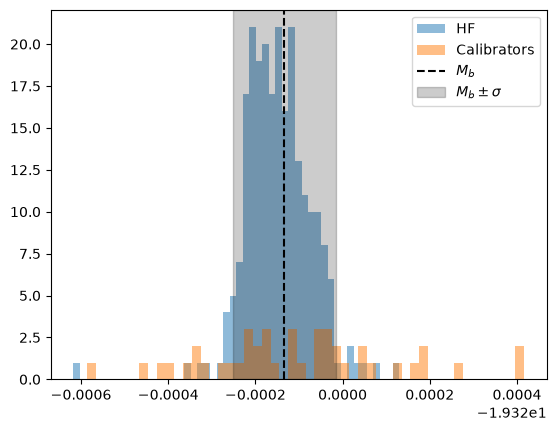

In [19]:
from matplotlib import pyplot as plt

H0, M_b, sigma, Mj_hf, Mj_calib = unpack(res.x)

print(H0)
print(M_b)
print(sigma)
fig, ax = plt.subplots()
ax.hist(Mj_hf, bins=50, alpha=0.5, label="HF")
ax.hist(Mj_calib, bins=50, alpha=0.5, label="Calibrators")
ax.axvline(M_b, color="k", linestyle="--", label="$M_b$")
ax.axvspan(M_b - sigma, M_b + sigma, color="k", alpha=0.2, label="$M_b \\pm \\sigma$")
ax.legend()

In [20]:
import scipy.stats
from tqdm import trange


def metropolis_hastings_step(theta: np.ndarray):
    # print(theta)
    for try_ in range(10000):
        proposal = theta + np.random.normal(scale=np.array([0.5, *[0.01] * (len(theta) - 1)]))
        acceptance_prob = min(1, np.exp(logpost(proposal) - logpost(theta)))
        if scipy.stats.uniform.rvs() < acceptance_prob:
            return proposal, try_ + 1
    raise RuntimeError("failed to accept a proposal after 1000 attempts")


def metropolis_hastings(theta0=x0, n_steps: int = 5000):
    chain = []
    tries = []
    theta = theta0
    for _ in trange(n_steps):
        chain.append(theta)
        theta, try_ = metropolis_hastings_step(theta)
        tries.append(try_)
    chain.append(theta)
    return chain, tries

In [90]:
chain, tries = metropolis_hastings(n_steps=20000)
chain = chain[1000::2]  # burn-in + thinning

100%|██████████| 20000/20000 [02:04<00:00, 160.41it/s]


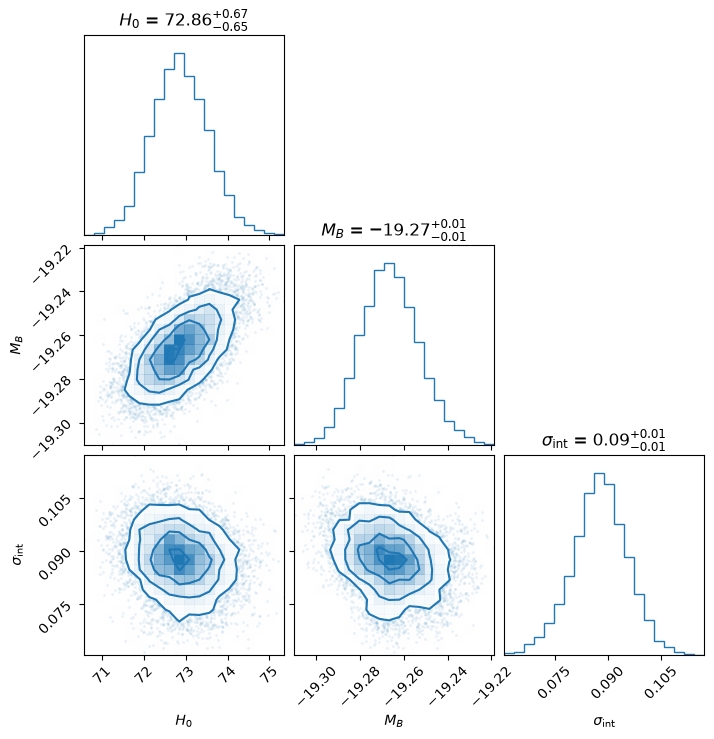

In [91]:
import corner

labels = ["$H_0$", "$M_B$", "$\\sigma_\\text{int}$"]

fig = corner.corner(
    np.array(chain)[:, :3],
    labels=labels,
    show_titles=True,
    color="tab:blue",
)
# corner.overplot_lines(fig, res.x[:3], color="r")

Text(0.5, 0, 'Step')

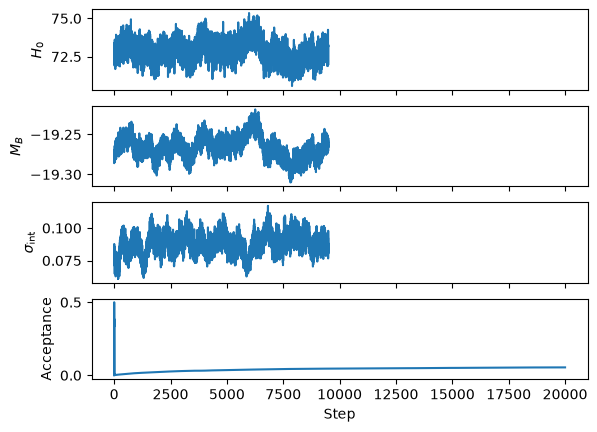

In [92]:
fig, ax = plt.subplots(nrows=4, ncols=1, sharex=True)

for chain_ in (chain,):
    for i, label in zip(range(len(chain_[0])), labels):
        ax[i].plot([theta[i] for theta in chain_])
        ax[i].set_ylabel(label)

for tries_ in (tries,):
    t = np.array([1, *tries_])
    tries_cumulative = np.cumsum(t)
    ax[-1].plot(np.arange(len(tries_cumulative)) / tries_cumulative)

# ax[-1].set_yscale("log")
ax[-1].set_ylabel("Acceptance")

ax[-1].set_xlabel("Step")

# HMC with PyMC/NUTS

In [93]:
# def logpost(theta: np.ndarray) -> float:
#     H0, M_b, sigma, Mj_hf, Mj_calib = unpack(theta)
#     if H0 < 0:
#         return -np.inf
#     if sigma <= 0:
#         return -np.inf
#     logprior = -0.5 * (sigma / 0.2) ** 2
#     return loglike(H0, M_b, sigma, Mj_hf, Mj_calib) + logprior

# def loglike(H0: float, M_B: float, sigma_int: float, Mj_hf: np.ndarray, Mj_calib: np.ndarray) -> float:
#     return -0.5 * (
#         np.sum(((Mj_hf - M_B) / sigma_int) ** 2)  # Mj prior folded into the likelihood
#         + np.sum(((Mj_calib - M_B) / sigma_int) ** 2)
#         + np.sum(((hf_sample.m_b - m_b_hf(H0, Mj_hf)) / hf_sample.m_b_err) ** 2)
#         + np.sum(((calib_sample.m_b - m_b_calib(Mj_calib)) / calib_sample.m_b_err) ** 2)
#     ) - (len(Mj_hf) + len(Mj_calib)) * np.log(sigma_int)

In [86]:
import pymc as pm

with pm.Model() as model:
    H0 = pm.Uniform("H0", lower=30, upper=120)
    M_b = pm.Uniform("M_b", lower=-25, upper=-15)
    sigma = pm.HalfNormal("sigma", sigma=0.2)
    Mj_hf = pm.Normal("Mj_hf", mu=M_b, sigma=sigma, shape=hf_sample.unique_sn_count)
    Mj_calib = pm.Normal("Mj_calib", mu=M_b, sigma=sigma, shape=calib_sample.unique_sn_count)

    observed_hf = pm.Normal(
        "observed_hf",
        mu=m_b_hf(H0, Mj_hf),
        sigma=hf_sample.m_b_err,
        observed=hf_sample.m_b,
    )
    observed_calib = pm.Normal(
        "observed_calib",
        mu=m_b_calib(Mj_calib),
        sigma=calib_sample.m_b_err,
        observed=calib_sample.m_b,
    )

    idata = pm.sample(
        200_000,
        initvals={
            "H0": 70.0,
            "M_b": -19.3,
            "sigma": 0.01,
            "Mj_hf": np.full(hf_sample.unique_sn_count, -19.3),
            "Mj_calib": np.full(calib_sample.unique_sn_count, -19.3),
        },
    )

NUTS[nutpie]: [H0, M_b, sigma, Mj_hf, Mj_calib]


Output()

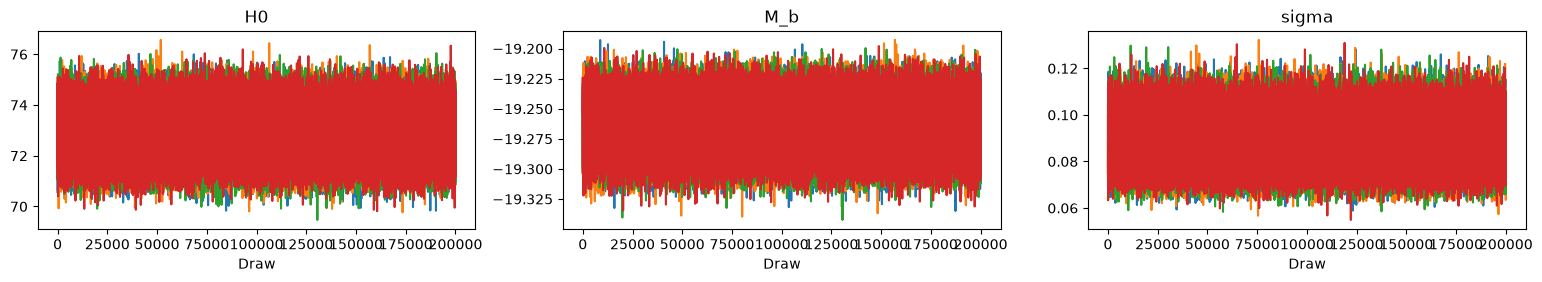

In [87]:
import arviz as az

az.plot_trace(idata, var_names=["H0", "M_b", "sigma"]);

In [106]:
post = idata.posterior.to_dataset()  # DataTree node -> Dataset
nuts_sample = np.column_stack([post[n].values.ravel() for n in names])

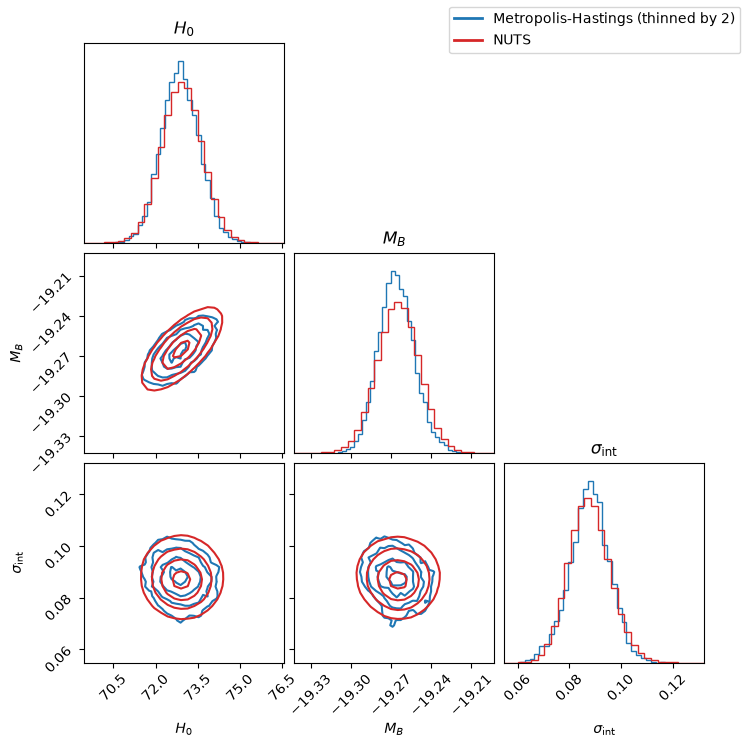

In [ ]:
import corner

labels = ["$H_0$", "$M_B$", "$\\sigma_\\text{int}$"]

kw = lambda col: dict(  # noqa: C408
    color=col,
    labels=labels,
    show_titles=True,
    plot_datapoints=False,
    plot_density=False,
    smooth=0.5,
    hist_kwargs={"density": True, "color": col},
    bins=30,
    title_fmt=None,
)

fig = corner.corner(
    np.array(chain)[:, :3],
    **kw("tab:blue"),
)

fig = corner.corner(
    nuts_sample,
    fig=fig,
    **kw("tab:red"),
)

fig.legend(
    handles=[
        plt.Line2D([0], [0], color="tab:blue", lw=2, label="Metropolis-Hastings (thinned by 2)"),
        plt.Line2D([0], [0], color="tab:red", lw=2, label="NUTS"),
    ]
)